Develop a program to demonstrate the working of Linear Regression and Polynomial Regression. Use 
Boston Housing Dataset for Linear Regression and Auto MPG Dataset (for vehicle fuel efficiency prediction) 
for Polynomial Regression. 

In [1]:
from sklearn.datasets import fetch_openml

In [ ]:
boston = fetch_openml(name="boston", version=1)

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [6]:
import pandas as pd

In [7]:
df = pd.DataFrame(boston.data, columns=boston.feature_names)
df["Target"] = boston.target

In [9]:
x = df[["RM"]]
y = df["Target"]

In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xtest, ytrain, ytest = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
predict = LinearRegression().fit(xtrain,ytrain).predict(xtest)

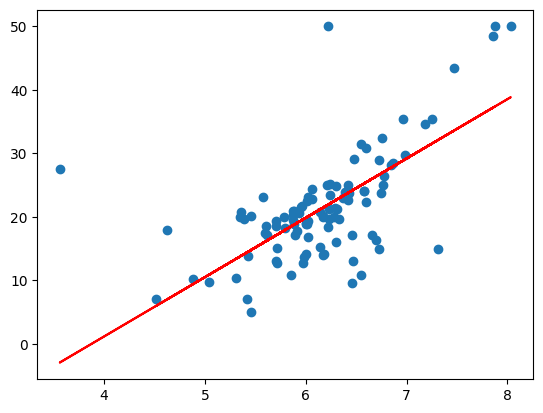

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(xtest,ytest)
plt.plot(xtest,predict, c="red")

In [16]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
data = pd.read_csv(url)
data

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [19]:
data = data.dropna()

In [30]:
predict = make_pipeline(PolynomialFeatures(degree=2), LinearRegression()).fit(data[["horsepower"]], data["mpg"]).predict(data[["horsepower"]])

In [24]:
import seaborn as sns

<Axes: xlabel='horsepower'>

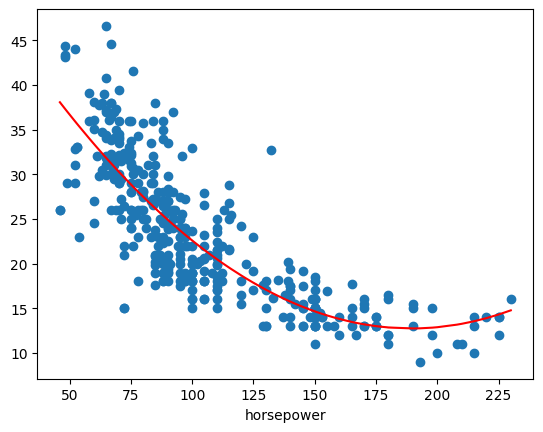

In [28]:
plt.scatter(data["horsepower"], data["mpg"])
sns.lineplot(x=data["horsepower"], y=predict, c="red")